<a href="https://colab.research.google.com/github/EmiiFernandez/actividades_data_sciente_ypf/blob/main/notebook/C07_Notebook-11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 🤖 Guía de Asistencia con IA: Estandarización y Codificación de Variables (Feature Engineering)

En esta notebook, utilizaremos la Inteligencia Artificial como copiloto de aprendizaje. Aquí tienes algunas sugerencias de cómo interactuar con un asistente de IA (como Gemini o ChatGPT):

- **Elegir Encoding**: Pídele consejo: *'Tengo una variable categórica 'Ciudad' con 30 valores únicos. ¿Es mejor usar One-Hot Encoding o Target Encoding? ¿Cómo lo hago con scikit-learn?'*.
- **Cuándo escalar**: Pregúntale: *'¿Por qué los modelos basados en distancia (como KNN o SVM) necesitan que los datos estén estandarizados, y por qué a los árboles de decisión no les afecta?'*.


# Programa Ingenias+ Data Science

Ya dijimos previamente que un proyecto de data science tiene varias etapas:

1. Recolección de Datos
2. Exploración y Procesamiento de los datos
3. Modelado
4. Puesta en Producción

En la clase anterior, hicimos el analisis exploratorio de los datos y pudimos observar el tipo de datos que teniamos. Pudimos hacernos preguntas y ver algunos patrones. Todo ese conocimiento que adquirimos es útil para llevar a cabo la próxima parte de esta etapa: el procesamiento de los datos.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

<font size=5>  🚀 Procesamiento de datos 👩🏽‍💻</font>

Una vez que visualizamos y exploramos el dataset tenemos una idea de como lucen nuestros datos. Es por eso que ahora debemos empezar a preparar nuestros datos para los siguientes pasos según lo que aprendimos de ellos y las preguntas que nos planteamos.

In [38]:
blackfriday = pd.read_csv('https://raw.githubusercontent.com/BelenUrdangarin/Entregables---Urdangarin/refs/heads/main/black_friday_reducido.csv', sep=';')
blackfriday.head(10)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00248942,F,15.0,NaN,A,2,0,1,6.0,14.0,15200.0
1,1000001,P00087842,NaN,15.0,10.0,A,2,0,12,NaN,NaN,1422.0
2,1000001,P00085442,F,15.0,10.0,A,2,0,12,14.0,NaN,1057.0
3,1000003,P00193542,M,28.0,15.0,A,3,0,1,2.0,NaN,15227.0
4,1000004,P0097242,M,48.0,NaN,B,2,1,1,16.0,NaN,15686.0
5,1000005,P00251242,M,26.0,20.0,A,1,1,5,11.0,NaN,5254.0
6,1000006,P00190242,F,53.0,9.0,A,1,0,4,5.0,NaN,2079.0
7,1000008,P00249542,M,27.0,12.0,C,4,1,1,5.0,15.0,19614.0
8,1000008,P00214442,M,33.0,12.0,C,4,1,8,NaN,NaN,5982.0
9,1000009,P00135742,M,30.0,17.0,C,0,0,6,8.0,NaN,16662.0


#### 1) TRANSFORMACION DE VARIABLES

- La mayoría de los algoritmos de machine learning no admiten `strings` como variables y requieren que las variables sean numericas. Por ese motivo, es necesario convertir las variables categoricas en su representación numerica. Para esto hay varias opciones que iremos viendo.

**`LabelEncoder()`**

In [39]:
from sklearn.preprocessing import LabelEncoder # Con Label encoder lo que hacemos es cambiar una categoria que tenia nombre por ejemplo de ciudades en que las ponga 0,1,2,3, ect

In [40]:
test_encoder = LabelEncoder() #Ejecutamos la función

In [41]:
blackfriday.loc[:, 'City_Category'] = test_encoder.fit_transform(blackfriday['City_Category']) ##mal porque estoy encodeando una variable predictiva

In [42]:
blackfriday.head(10)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00248942,F,15.0,NaN,0,2,0,1,6.0,14.0,15200.0
1,1000001,P00087842,NaN,15.0,10.0,0,2,0,12,NaN,NaN,1422.0
2,1000001,P00085442,F,15.0,10.0,0,2,0,12,14.0,NaN,1057.0
3,1000003,P00193542,M,28.0,15.0,0,3,0,1,2.0,NaN,15227.0
4,1000004,P0097242,M,48.0,NaN,1,2,1,1,16.0,NaN,15686.0
5,1000005,P00251242,M,26.0,20.0,0,1,1,5,11.0,NaN,5254.0
6,1000006,P00190242,F,53.0,9.0,0,1,0,4,5.0,NaN,2079.0
7,1000008,P00249542,M,27.0,12.0,2,4,1,1,5.0,15.0,19614.0
8,1000008,P00214442,M,33.0,12.0,2,4,1,8,NaN,NaN,5982.0
9,1000009,P00135742,M,30.0,17.0,2,0,0,6,8.0,NaN,16662.0


**`get_dummies()`**

In [43]:
pd.get_dummies(blackfriday["Gender"]) ##falta el drop first y si quiero 1 y 0 el dtype int

,F,M
0,True,False
1,False,False
2,True,False
3,False,True
4,False,True
...,...,...
188318,False,True
188319,False,True
188320,False,True
188321,False,True


In [44]:
blackfriday[['female', 'male']] = pd.get_dummies(blackfriday["Gender"])

In [45]:
blackfriday.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,female,male
0,1000001,P00248942,F,15.0,NaN,0,2,0,1,6.0,14.0,15200.0,True,False
1,1000001,P00087842,NaN,15.0,10.0,0,2,0,12,NaN,NaN,1422.0,False,False
2,1000001,P00085442,F,15.0,10.0,0,2,0,12,14.0,NaN,1057.0,True,False
3,1000003,P00193542,M,28.0,15.0,0,3,0,1,2.0,NaN,15227.0,False,True
4,1000004,P0097242,M,48.0,NaN,1,2,1,1,16.0,NaN,15686.0,False,True


**`OneHotEncoder()`**

In [46]:
from sklearn.preprocessing import OneHotEncoder

In [47]:
blackfriday['Gender'].unique()

array(['F', nan, 'M'], dtype=object)

In [48]:
gender_encoder = OneHotEncoder() ##si hago drop first despues no puede pedir categorias

In [49]:
gender_encoder.fit_transform(blackfriday[['Gender']]).toarray()

array([[1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       ...,
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.]])

In [50]:
gender_encoder.categories_

[array(['F', 'M', nan], dtype=object)]

In [51]:
niveles = gender_encoder.categories_[0].tolist() ##get_features_name_out

In [52]:
one_hot_gender = pd.DataFrame(gender_encoder.fit_transform(blackfriday[['Gender']]).toarray(), columns=niveles)

In [53]:
one_hot_gender

,F,M,NaN
0,1.0,0.0,0.0
1,0.0,0.0,1.0
2,1.0,0.0,0.0
3,0.0,1.0,0.0
4,0.0,1.0,0.0
...,...,...,...
188318,0.0,1.0,0.0
188319,0.0,1.0,0.0
188320,0.0,1.0,0.0
188321,0.0,1.0,0.0


In [54]:
new_df = pd.concat([blackfriday, one_hot_gender], axis=1)

In [55]:
new_df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,female,male,F,M,NaN
0,1000001,P00248942,F,15.0,NaN,0,2,0,1,6.0,14.0,15200.0,True,False,1.0,0.0,0.0
1,1000001,P00087842,NaN,15.0,10.0,0,2,0,12,NaN,NaN,1422.0,False,False,0.0,0.0,1.0
2,1000001,P00085442,F,15.0,10.0,0,2,0,12,14.0,NaN,1057.0,True,False,1.0,0.0,0.0
3,1000003,P00193542,M,28.0,15.0,0,3,0,1,2.0,NaN,15227.0,False,True,0.0,1.0,0.0
4,1000004,P0097242,M,48.0,NaN,1,2,1,1,16.0,NaN,15686.0,False,True,0.0,1.0,0.0


**`binning`**

In [56]:
print(blackfriday.Age.min())
print(blackfriday.Age.max())

14.0
74.0


In [57]:
blackfriday["Age"] = pd.to_numeric(blackfriday["Age"], errors='coerce')

In [58]:
bin_age = [10, 21, 60, 80]
labels = ["Adolescente", "Adulto", "Anciano"]

age_categories = pd.cut(blackfriday["Age"], bins=bin_age, labels=labels)

In [59]:
age_categories

,Age
0,Adolescente
1,Adolescente
2,Adolescente
3,Adulto
4,Adulto
...,...
188318,Adulto
188319,Adulto
188320,Adulto
188321,Adulto


/tmp/ipykernel_1391/3638997116.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_counts.index, y=age_counts.values, palette='viridis')


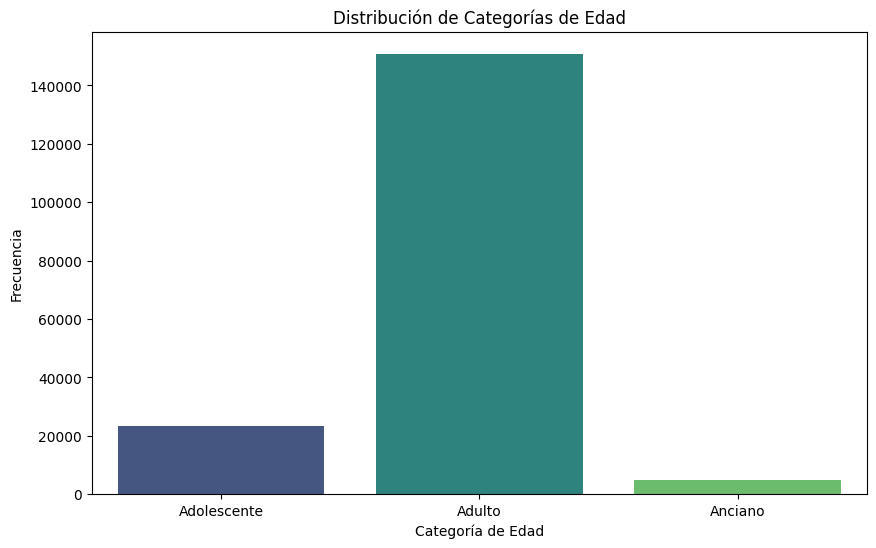

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get the value counts of the age categories
age_counts = age_categories.value_counts().sort_index()

# Create a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=age_counts.index, y=age_counts.values, palette='viridis')
plt.title('Distribución de Categorías de Edad')
plt.xlabel('Categoría de Edad')
plt.ylabel('Frecuencia')
plt.show()

Fértil Temprana (15 a 24 años): Alta fertilidad, inicio de la edad reproductiva.
Fértil Pico (25 a 34 años): Máxima madurez reproductiva y estabilidad biológica.
Fértil Tardía (35 a 44 años): Descenso gradual de la reserva ovárica.
Transición / Post-fértil (45 años o más): Climaterio, menopausia y etapa posterior.

In [61]:
analisis3 = pd.read_csv('https://raw.githubusercontent.com/BelenUrdangarin/Entregables---Urdangarin/refs/heads/main/black_friday_reducido.csv', sep=';')
analisis3.head(10)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00248942,F,15.0,NaN,A,2,0,1,6.0,14.0,15200.0
1,1000001,P00087842,NaN,15.0,10.0,A,2,0,12,NaN,NaN,1422.0
2,1000001,P00085442,F,15.0,10.0,A,2,0,12,14.0,NaN,1057.0
3,1000003,P00193542,M,28.0,15.0,A,3,0,1,2.0,NaN,15227.0
4,1000004,P0097242,M,48.0,NaN,B,2,1,1,16.0,NaN,15686.0
5,1000005,P00251242,M,26.0,20.0,A,1,1,5,11.0,NaN,5254.0
6,1000006,P00190242,F,53.0,9.0,A,1,0,4,5.0,NaN,2079.0
7,1000008,P00249542,M,27.0,12.0,C,4,1,1,5.0,15.0,19614.0
8,1000008,P00214442,M,33.0,12.0,C,4,1,8,NaN,NaN,5982.0
9,1000009,P00135742,M,30.0,17.0,C,0,0,6,8.0,NaN,16662.0


In [62]:
rangos_fertiles = [13, 25 , 35, 45, analisis3["Age"].max() + 1]
labels = ["Fertil Temprana", "Fertil Pico", "Fertil Tardía" , "Transición / Post-fértil"]

analisis3["Rango Biologico"] = pd.cut(analisis3["Age"], bins=rangos_fertiles, labels=labels)

In [63]:
analisis3['Rango Biologico'].unique()

['Fertil Temprana', 'Fertil Pico', 'Transición / Post-fértil', 'Fertil Tardía', NaN]
Categories (4, object): ['Fertil Temprana' < 'Fertil Pico' < 'Fertil Tardía' <
                         'Transición / Post-fértil']

In [64]:
rangos_fertiles_encoder = OneHotEncoder()

In [65]:
rangos_fertiles_encoder.fit_transform(analisis3[['Rango Biologico']]).toarray()

array([[0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.],
       ...,
       [0., 0., 1., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.]])

In [66]:
rangos_fertiles_encoder.categories_

[array(['Fertil Pico', 'Fertil Tardía', 'Fertil Temprana',
        'Transición / Post-fértil', nan], dtype=object)]

In [67]:
niveles = rangos_fertiles_encoder.categories_[0].tolist()

In [68]:
one_hot_rango = pd.DataFrame(rangos_fertiles_encoder.fit_transform(analisis3[['Rango Biologico']]).toarray(), columns=niveles)
one_hot_rango

,Fertil Pico,Fertil Tardía,Fertil Temprana,Transición / Post-fértil,NaN
0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...
188318,0.0,0.0,1.0,0.0,0.0
188319,0.0,0.0,1.0,0.0,0.0
188320,0.0,0.0,1.0,0.0,0.0
188321,0.0,1.0,0.0,0.0,0.0


In [69]:
new_df_analisis3 = pd.concat([analisis3, one_hot_rango], axis=1)

In [70]:
new_df_analisis3.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,Rango Biologico,Fertil Pico,Fertil Tardía,Fertil Temprana,Transición / Post-fértil,NaN
0,1000001,P00248942,F,15.0,NaN,A,2,0,1,6.0,14.0,15200.0,Fertil Temprana,0.0,0.0,1.0,0.0,0.0
1,1000001,P00087842,NaN,15.0,10.0,A,2,0,12,NaN,NaN,1422.0,Fertil Temprana,0.0,0.0,1.0,0.0,0.0
2,1000001,P00085442,F,15.0,10.0,A,2,0,12,14.0,NaN,1057.0,Fertil Temprana,0.0,0.0,1.0,0.0,0.0
3,1000003,P00193542,M,28.0,15.0,A,3,0,1,2.0,NaN,15227.0,Fertil Pico,1.0,0.0,0.0,0.0,0.0
4,1000004,P0097242,M,48.0,NaN,B,2,1,1,16.0,NaN,15686.0,Transición / Post-fértil,0.0,0.0,0.0,1.0,0.0


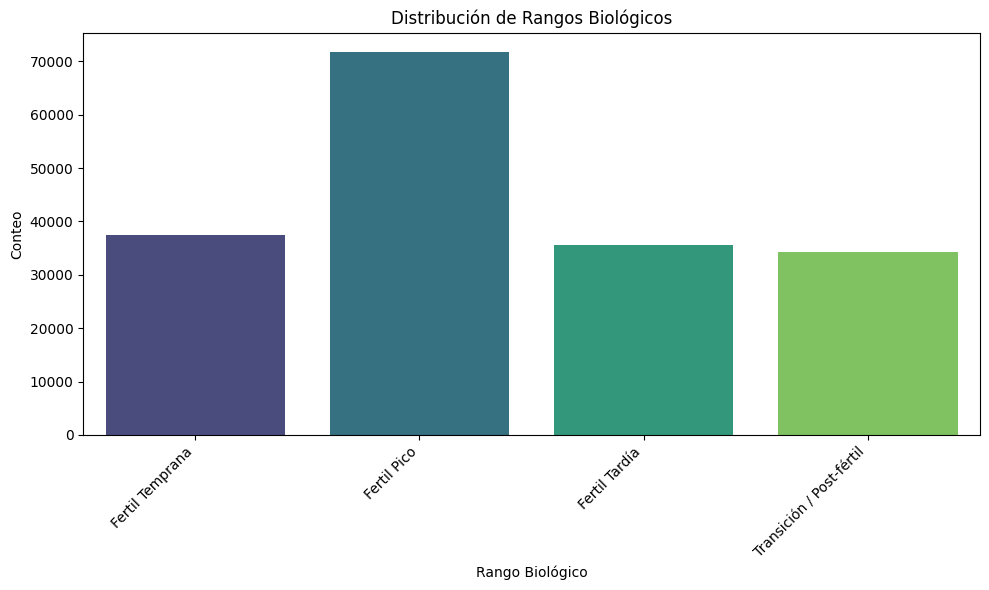

In [71]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Rango Biologico', data=analisis3, palette='viridis', hue='Rango Biologico', legend=False)
plt.title('Distribución de Rangos Biológicos')
plt.xlabel('Rango Biológico')
plt.ylabel('Conteo')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [72]:
pd.get_dummies(analisis3["Rango Biologico"]) ##pasa a variables categoricas

,Fertil Temprana,Fertil Pico,Fertil Tardía,Transición / Post-fértil
0,True,False,False,False
1,True,False,False,False
2,True,False,False,False
3,False,True,False,False
4,False,False,False,True
...,...,...,...,...
188318,True,False,False,False
188319,True,False,False,False
188320,True,False,False,False
188321,False,False,True,False


In [73]:
analisis3.head(10)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,Rango Biologico
0,1000001,P00248942,F,15.0,NaN,A,2,0,1,6.0,14.0,15200.0,Fertil Temprana
1,1000001,P00087842,NaN,15.0,10.0,A,2,0,12,NaN,NaN,1422.0,Fertil Temprana
2,1000001,P00085442,F,15.0,10.0,A,2,0,12,14.0,NaN,1057.0,Fertil Temprana
3,1000003,P00193542,M,28.0,15.0,A,3,0,1,2.0,NaN,15227.0,Fertil Pico
4,1000004,P0097242,M,48.0,NaN,B,2,1,1,16.0,NaN,15686.0,Transición / Post-fértil
5,1000005,P00251242,M,26.0,20.0,A,1,1,5,11.0,NaN,5254.0,Fertil Pico
6,1000006,P00190242,F,53.0,9.0,A,1,0,4,5.0,NaN,2079.0,Transición / Post-fértil
7,1000008,P00249542,M,27.0,12.0,C,4,1,1,5.0,15.0,19614.0,Fertil Pico
8,1000008,P00214442,M,33.0,12.0,C,4,1,8,NaN,NaN,5982.0,Fertil Pico
9,1000009,P00135742,M,30.0,17.0,C,0,0,6,8.0,NaN,16662.0,Fertil Pico
